In [87]:
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker


df = pd.read_csv('../csv_files/highest_paying_job_titles.csv')
df = df.rename(columns = {"job_title_short": "Job Title", "job_posted_count": "Job Postings"})
df['Average Salary'] = df['job_salary_average'].apply(lambda x: f"${x:,.2f}")


df2 = df.sort_values(by = "Job Postings", ascending=False)
df2['Formatted Job Postings'] = df2['Job Postings'].apply(lambda x: f"{x:,.0f}")
df.head()



,Job Title,job_salary_average,Job Postings,Average Salary
0,Senior Data Scientist,154050,1686,"$154,050.00"
1,Senior Data Engineer,145867,1594,"$145,867.00"
2,Data Scientist,135929,5926,"$135,929.00"
3,Data Engineer,130267,4509,"$130,267.00"
4,Machine Learning Engineer,126786,573,"$126,786.00"


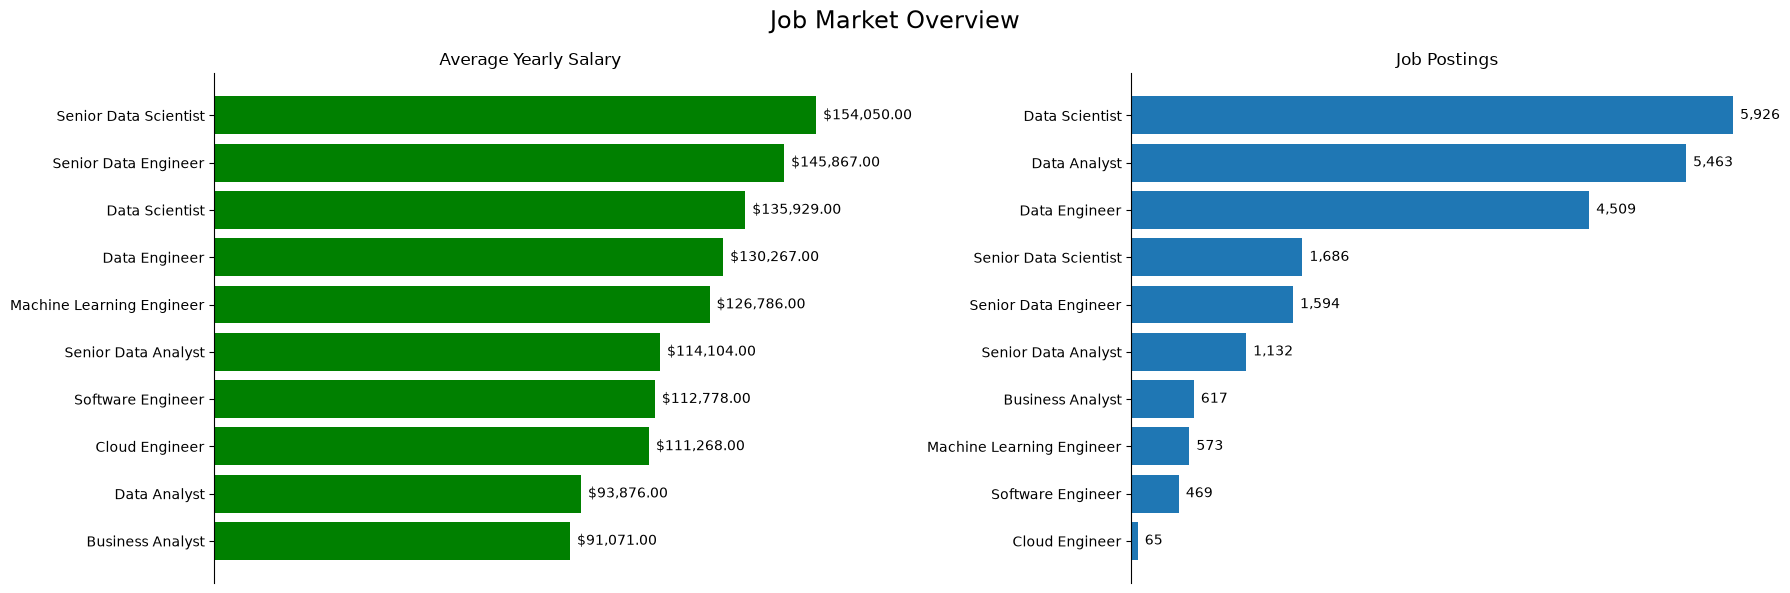

In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (18,6))
hbar1 = ax1.barh(df['Job Title'], df['job_salary_average'], color = 'green')
ax1.bar_label(hbar1, padding = 5, labels = df["Average Salary"])
ax1.get_xaxis().set_visible(False)
ax1.set_title('Average Yearly Salary')
ax1.invert_yaxis()


hbar2 = ax2.barh(df2['Job Title'], df2['Job Postings'])
ax2.bar_label(hbar2, padding = 5, labels = df2['Formatted Job Postings'])
ax2.set_title('Job Postings')
ax2.get_xaxis().set_visible(False)
ax2.invert_yaxis()

ax1.spines[['top', 'right', 'bottom']].set_visible(False)
ax2.spines[['top', 'right', 'bottom']].set_visible(False)

plt.suptitle("Job Market Overview", fontsize = 'xx-large')
plt.tight_layout()
plt.show()


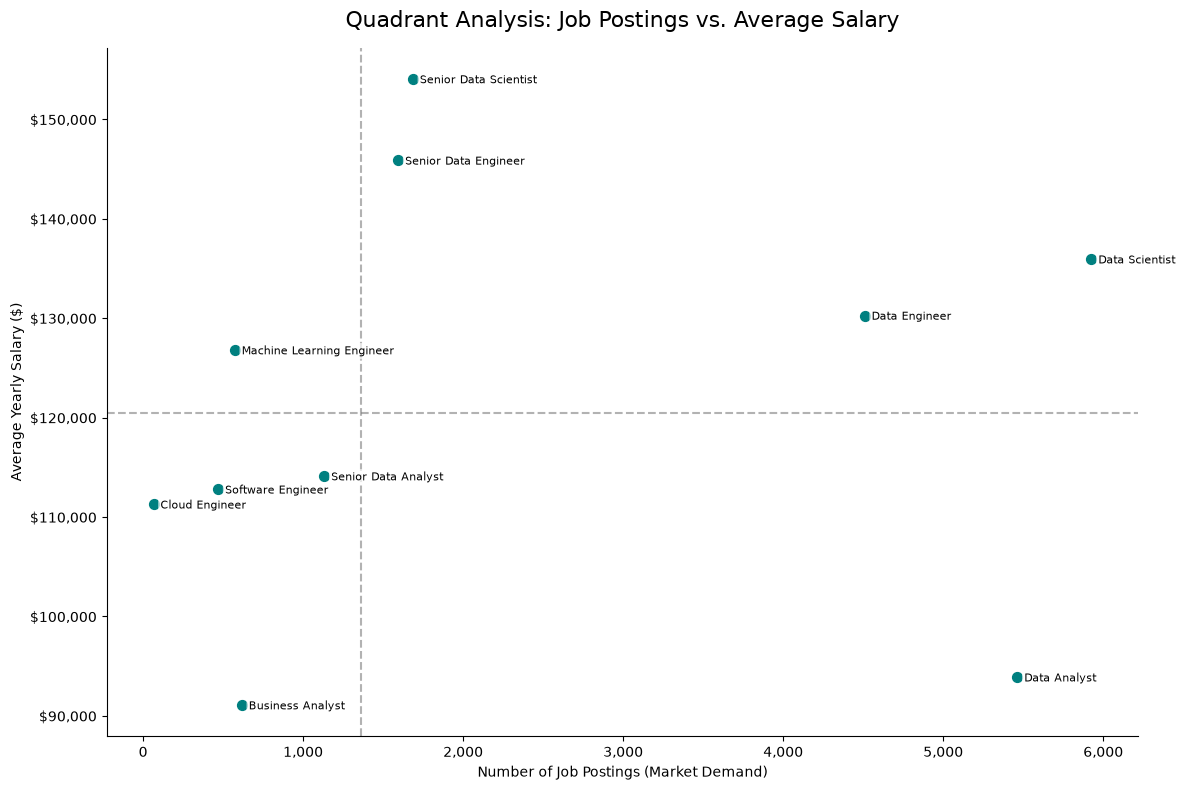

In [89]:
#print(df.shape)
median_salary = df['job_salary_average'].median()
median_postings = df['Job Postings'].median()

fig, ax = plt.subplots(figsize = (12,8))

ax.scatter(df['Job Postings'], df['job_salary_average'], color='#008080', s = 50)
ax.axhline(median_salary, color = 'gray', linestyle = '--', alpha = 0.6)
ax.axvline(median_postings, color = 'gray', linestyle = '--', alpha = 0.6)

for i, row in df.iterrows():
    ax.annotate(row['Job Title'], 
                (row['Job Postings'], row['job_salary_average']),
                xytext=(5, -3), 
                textcoords='offset points', 
                fontsize=8, bbox = dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"${y:,.0f}"))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))
ax.set_title('Quadrant Analysis: Job Postings vs. Average Salary', fontsize=16, pad=15)
ax.set_xlabel('Number of Job Postings (Market Demand)')
ax.set_ylabel('Average Yearly Salary ($)')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [90]:
import pandas as pd 
import matplotlib.pyplot as plt 

df_skills= pd.read_csv('../csv_files/highest_paying_skills_all.csv')
df_skills.rename(columns = {'skill_count': '# of jobs for Skill'}, inplace=True)
df_skills['Formatted Salary'] = df_skills['skill_salary_average'].apply(lambda x: f"${x:,.2f}")
df_skills = df_skills.head(10)

df_skills2 = df_skills.sort_values(by = '# of jobs for Skill', ascending=False)
df_skills2['Formatted Jobs'] = df_skills['# of jobs for Skill'].apply(lambda x: f"{x:,.0f}")
df_skills2 = df_skills2.head(10)

df_skills.head()

,skills,# of jobs for Skill,skill_salary_average,Formatted Salary
0,mongo,262,170715,"$170,715.00"
1,dplyr,19,160667,"$160,667.00"
2,node,65,154408,"$154,408.00"
3,cassandra,530,154124,"$154,124.00"
4,watson,31,152844,"$152,844.00"


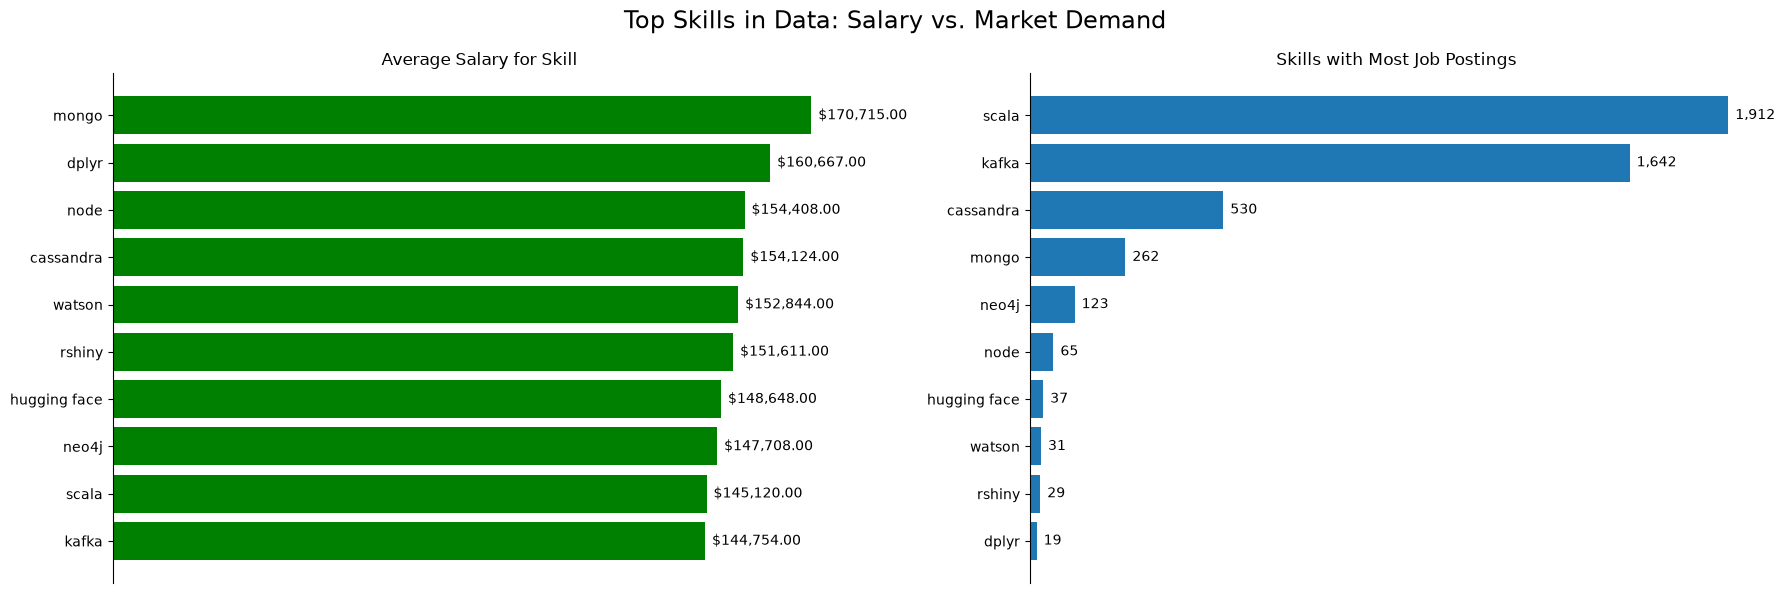

In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (18,6))
hbar1 = ax1.barh(df_skills['skills'], df_skills['skill_salary_average'], color = 'green')
ax1.bar_label(hbar1, padding = 5, labels = df_skills["Formatted Salary"])
ax1.get_xaxis().set_visible(False)
ax1.set_title('Average Salary for Skill')
ax1.invert_yaxis()


hbar2 = ax2.barh(df_skills2['skills'], df_skills2['# of jobs for Skill'])
ax2.bar_label(hbar2, padding = 5, labels = df_skills2['Formatted Jobs'])
ax2.set_title('Skills with Most Job Postings')
ax2.get_xaxis().set_visible(False)
ax2.invert_yaxis()

ax1.spines[['top', 'right', 'bottom']].set_visible(False)
ax2.spines[['top', 'right', 'bottom']].set_visible(False)

plt.suptitle("Top Skills in Data: Salary vs. Market Demand", fontsize = 'xx-large')
plt.tight_layout()
plt.show()